TRABAJO FINAL DEL MÀSTER

ESTUDIANTE: ESTEFANY SOLANGE YEPEZ CESEN

In [1]:
import pandas as pd

df = pd.DataFrame({
    'Año': [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Duracion_media': [37.80, 38.46, 39.51, 38.81, 43.46, 62.66, 62.65, 34.42, 47.43, 51.50, 50.84],
    'Incidencia_media': [20.51, 21.54, 22.77, 24.98, 24.57, 13.44, 16.80, 38.47, 27.28, 27.46, 28.46],
    'Procesos_iniciados': [298924, 326757, 355784, 403710, 1432548, 214261, 251060, 1594471, 1152055, 1185222, 1253214]
})

df

,Año,Duracion_media,Incidencia_media,Procesos_iniciados
0,2015,37.80,20.51,298924
1,2016,38.46,21.54,326757
2,2017,39.51,22.77,355784
3,2018,38.81,24.98,403710
4,2019,43.46,24.57,1432548
5,2020,62.66,13.44,214261
6,2021,62.65,16.80,251060
7,2022,34.42,38.47,1594471
8,2023,47.43,27.28,1152055
9,2024,51.50,27.46,1185222


In [3]:
df[['Duracion_media', 'Incidencia_media', 'Procesos_iniciados']].describe()

,Duracion_media,Incidencia_media,Procesos_iniciados
count,11.000000,11.000000,1.100000e+01
mean,46.140000,24.207273,7.698187e+05
std,9.842453,6.602374,5.452392e+05
min,34.420000,13.440000,2.142610e+05
25%,38.635000,21.025000,3.128405e+05
50%,43.460000,24.570000,4.037100e+05
75%,51.170000,27.370000,1.219218e+06
max,62.660000,38.470000,1.594471e+06


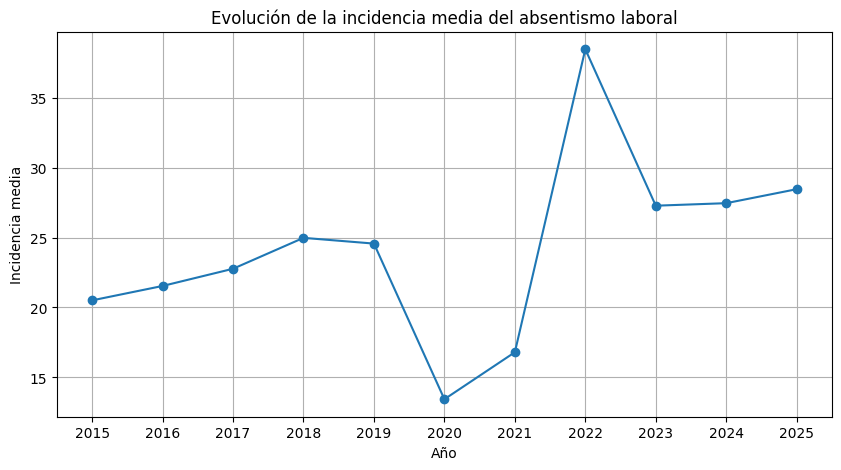

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Año'], df['Incidencia_media'], marker='o')
plt.title('Evolución de la incidencia media del absentismo laboral')
plt.xlabel('Año')
plt.ylabel('Incidencia media')
plt.xticks(df['Año'])
plt.grid(True)
plt.show()

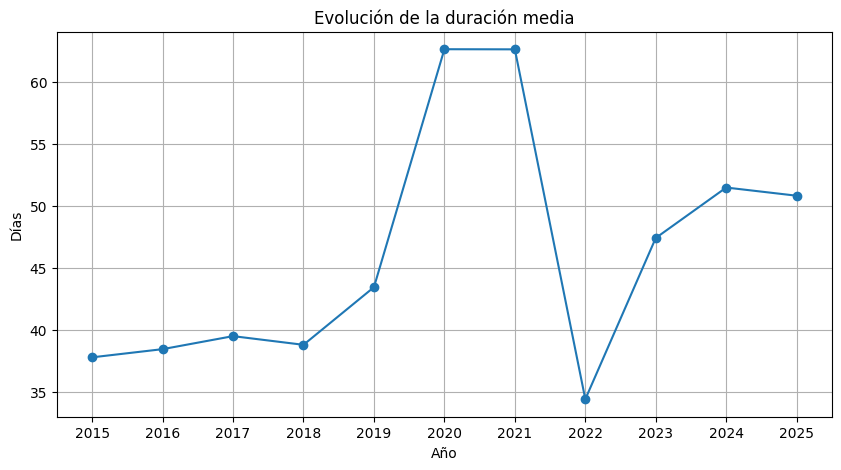

In [5]:
plt.figure(figsize=(10,5))
plt.plot(df['Año'], df['Duracion_media'], marker='o')
plt.title('Evolución de la duración media')
plt.xlabel('Año')
plt.ylabel('Días')
plt.xticks(df['Año'])
plt.grid(True)
plt.show()

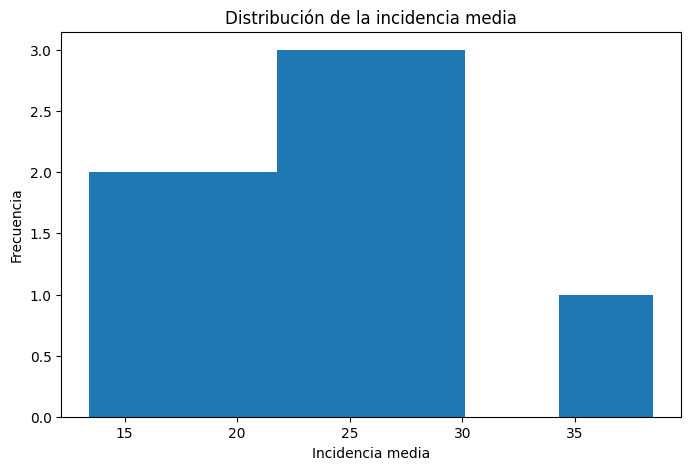

In [6]:
plt.figure(figsize=(8,5))
plt.hist(df['Incidencia_media'], bins=6)
plt.title('Distribución de la incidencia media')
plt.xlabel('Incidencia media')
plt.ylabel('Frecuencia')
plt.show()

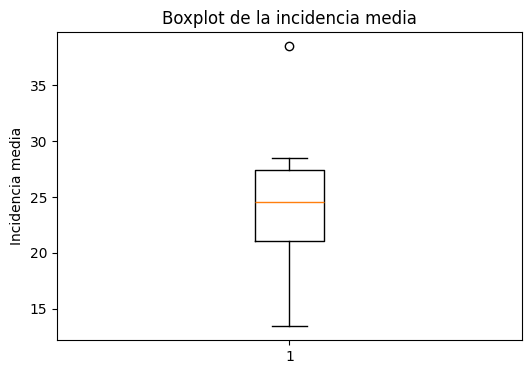

In [7]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Incidencia_media'])
plt.title('Boxplot de la incidencia media')
plt.ylabel('Incidencia media')
plt.show()

In [8]:
df = df.sort_values('Año').reset_index(drop=True)
df

,Año,Duracion_media,Incidencia_media,Procesos_iniciados
0,2015,37.80,20.51,298924
1,2016,38.46,21.54,326757
2,2017,39.51,22.77,355784
3,2018,38.81,24.98,403710
4,2019,43.46,24.57,1432548
5,2020,62.66,13.44,214261
6,2021,62.65,16.80,251060
7,2022,34.42,38.47,1594471
8,2023,47.43,27.28,1152055
9,2024,51.50,27.46,1185222


In [9]:
serie = df['Incidencia_media']
serie

0     20.51
1     21.54
2     22.77
3     24.98
4     24.57
5     13.44
6     16.80
7     38.47
8     27.28
9     27.46
10    28.46
Name: Incidencia_media, dtype: float64

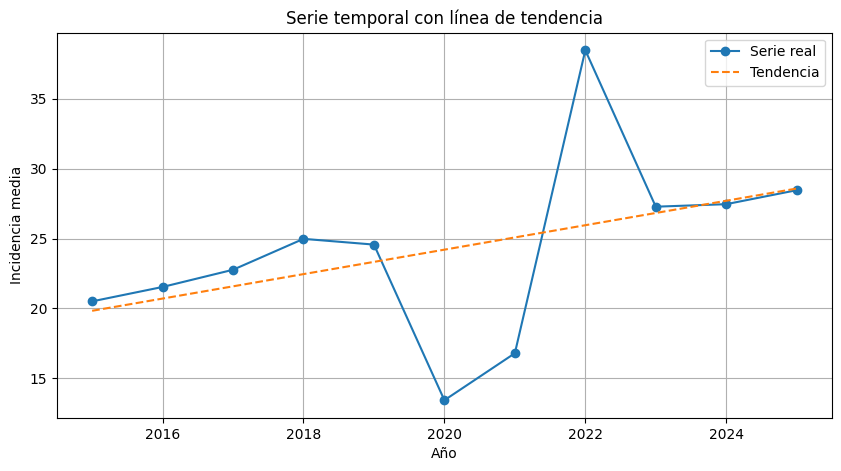

In [10]:
import numpy as np
import matplotlib.pyplot as plt

x = df['Año']
y = df['Incidencia_media']

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.figure(figsize=(10,5))
plt.plot(x, y, marker='o', label='Serie real')
plt.plot(x, p(x), linestyle='--', label='Tendencia')
plt.xlabel('Año')
plt.ylabel('Incidencia media')
plt.title('Serie temporal con línea de tendencia')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
from statsmodels.tsa.stattools import adfuller

resultado = adfuller(df['Incidencia_media'])

print('ADF Statistic:', resultado[0])
print('p-value:', resultado[1])

ADF Statistic: -2.838020892148858
p-value: 0.053044636966766374


In [12]:
df['Incidencia_diff'] = df['Incidencia_media'].diff()
df

,Año,Duracion_media,Incidencia_media,Procesos_iniciados,Incidencia_diff
0,2015,37.80,20.51,298924,NaN
1,2016,38.46,21.54,326757,1.03
2,2017,39.51,22.77,355784,1.23
3,2018,38.81,24.98,403710,2.21
4,2019,43.46,24.57,1432548,-0.41
5,2020,62.66,13.44,214261,-11.13
6,2021,62.65,16.80,251060,3.36
7,2022,34.42,38.47,1594471,21.67
8,2023,47.43,27.28,1152055,-11.19
9,2024,51.50,27.46,1185222,0.18


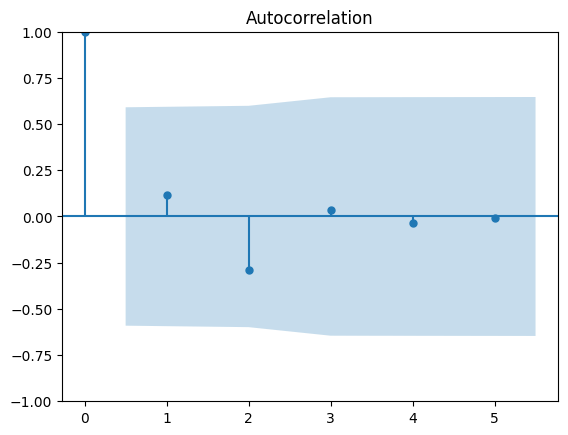

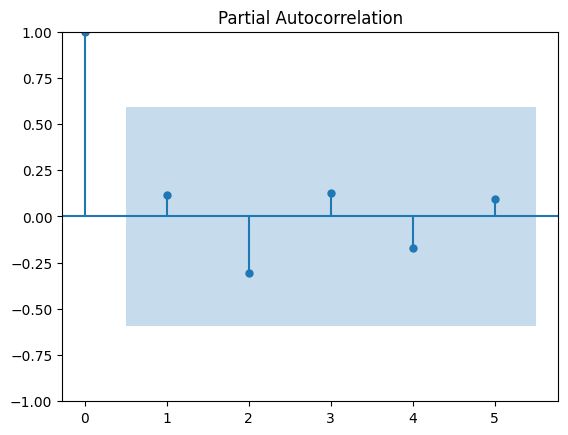

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['Incidencia_media'])
plt.show()

plot_pacf(df['Incidencia_media'])
plt.show()

In [23]:
train = df[df['Año'] <= 2023]
test = df[df['Año'] > 2023]

In [24]:
from sklearn.linear_model import LinearRegression

X_train = train[['Año']]
y_train = train['Incidencia_media']

modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

LinearRegression()

In [25]:
print("Intercepto:", modelo_lr.intercept_)
print("Pendiente:", modelo_lr.coef_[0])


Intercepto: -1806.8501666666668
Pendiente: 0.9065000000000001


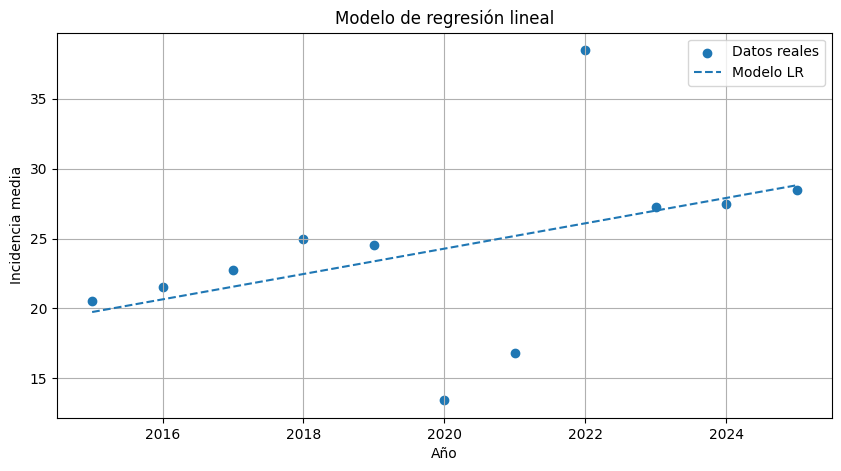

In [26]:
pred_total = modelo_lr.predict(df[['Año']])

plt.figure(figsize=(10,5))
plt.scatter(df['Año'], df['Incidencia_media'], label='Datos reales')
plt.plot(df['Año'], pred_total, linestyle='--', label='Modelo LR')
plt.xlabel('Año')
plt.ylabel('Incidencia media')
plt.title('Modelo de regresión lineal')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
X_test = test[['Año']]
y_test = test['Incidencia_media']

pred_lr = modelo_lr.predict(X_test)

pred_lr

array([27.90583333, 28.81233333])

In [19]:
from statsmodels.tsa.stattools import adfuller

resultado = adfuller(df['Incidencia_media'])

print("ADF Statistic:", resultado[0])
print("p-value:", resultado[1])

ADF Statistic: -2.838020892148858
p-value: 0.053044636966766374


In [20]:
from statsmodels.tsa.arima.model import ARIMA

modelo_arima = ARIMA(train['Incidencia_media'], order=(1,1,1))
resultado_arima = modelo_arima.fit()

print(resultado_arima.summary())

                               SARIMAX Results                                
Dep. Variable:       Incidencia_media   No. Observations:                    9
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -27.998
Date:                Tue, 31 Mar 2026   AIC                             61.996
Time:                        21:52:15   BIC                             62.234
Sample:                             0   HQIC                            60.388
                                  - 9                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1716      2.632      0.065      0.948      -4.988       5.331
ma.L1         -0.9966    185.451     -0.005      0.996    -364.475     362.481
sigma2        50.7931   9389.623      0.005      0.9

In [21]:
pred_arima = resultado_arima.forecast(steps=len(test))
pred_arima

9     24.062999
10    23.510939
Name: predicted_mean, dtype: float64

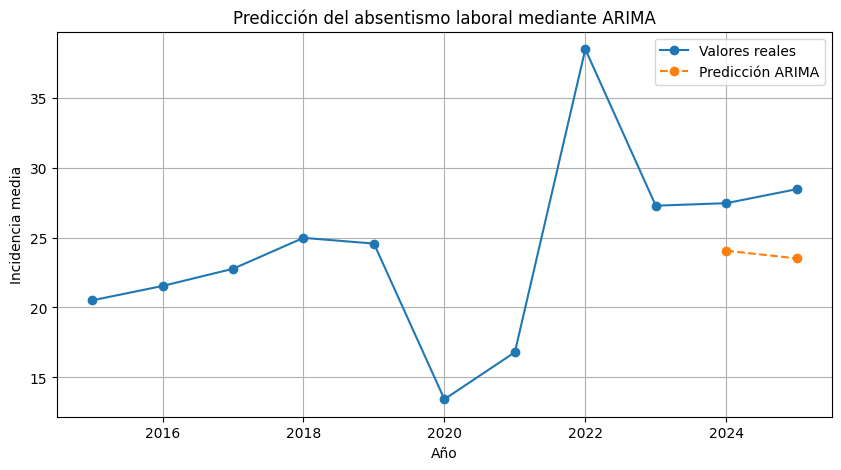

In [30]:
plt.figure(figsize=(10,5))

# serie real completa
plt.plot(df['Año'], df['Incidencia_media'], marker='o', label='Valores reales')

# predicción ARIMA solo en test
plt.plot(test['Año'], pred_arima, marker='o', linestyle='--', label='Predicción ARIMA')

plt.xlabel('Año')
plt.ylabel('Incidencia media')
plt.title('Predicción del absentismo laboral mediante ARIMA')
plt.legend()
plt.grid(True)
plt.show()

In [31]:
print(resultado_arima.params)

ar.L1      0.171607
ma.L1     -0.996553
sigma2    50.793056
dtype: float64


In [28]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)

modelo_rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [29]:
pred_rf = modelo_rf.predict(X_test)

pred_rf

array([28.2838, 28.2838])

In [32]:
print(modelo_rf)

RandomForestRegressor(random_state=42)


In [33]:
print(modelo_rf.feature_importances_)

[1.]


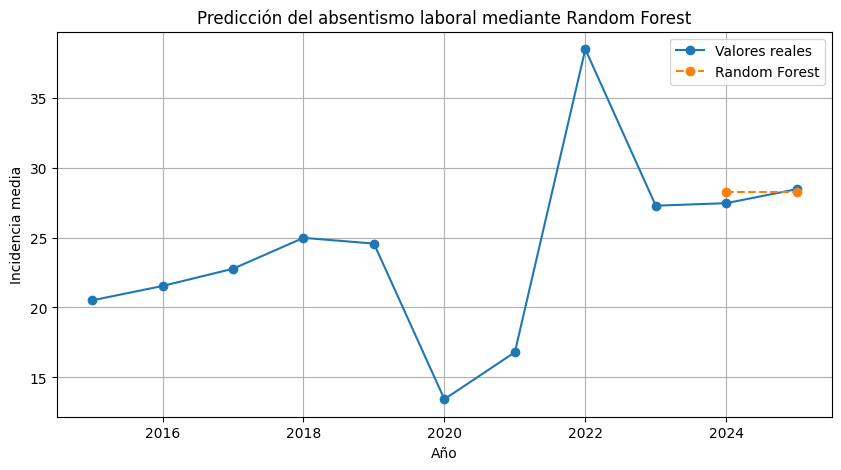

In [34]:
plt.figure(figsize=(10,5))

plt.plot(df['Año'], df['Incidencia_media'], marker='o', label='Valores reales')
plt.plot(test['Año'], pred_rf, marker='o', linestyle='--', label='Random Forest')

plt.xlabel('Año')
plt.ylabel('Incidencia media')
plt.title('Predicción del absentismo laboral mediante Random Forest')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Modelo 1: Regresión Lineal
mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)

# Modelo 2: ARIMA
mae_arima = mean_absolute_error(y_test, pred_arima)
rmse_arima = np.sqrt(mean_squared_error(y_test, pred_arima))
r2_arima = r2_score(y_test, pred_arima)

# Modelo 3: Random Forest
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

# Tabla comparativa
tabla_metricas = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'ARIMA', 'Random Forest'],
    'MAE': [mae_lr, mae_arima, mae_rf],
    'RMSE': [rmse_lr, rmse_arima, rmse_rf],
    'R²': [r2_lr, r2_arima, r2_rf]
})

tabla_metricas

,Modelo,MAE,RMSE,R²
0,Regresión Lineal,0.399083,0.401812,0.354188
1,ARIMA,4.173031,4.244574,-71.065637
2,Random Forest,0.500000,0.595690,-0.419386
